Interpolation: estimating values between known data points, creating a continous function thriough pointss
- linear interpolation assumes a straight line, makes a jagged curve and poor accuracy
- polynomial interpolation uses a curve, but this can lead to overfitting (runge's phenomenon)

a spline is a piecewise polynomial function that uses multiple lower degree functions between each pair of points to better represent the data
**goal is to not miss any points (knots)

cubic spline: piecewise cubic polynomial, fits cubic polynomials between consecutive data points, ensures smoothness, no overfitting, pretty stable


- spline must pass through all points
- first and second derivatives have to be continuous
    - tangent line between functions (so at a point) must be the same
- must have boundary conditions
    - natural spline: sencond derivative at endpoints is 0
    - clamped spline: first derivatives at the endpoints are specifiied


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
# Define known data points
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])
# Create a cubic spline interpolation of the data
cs = CubicSpline(x, y, bc_type='natural')
# Generate new x values for a smooth plot
x_interp = np.linspace(0, 5, 100)
y_interp = cs(x_interp)

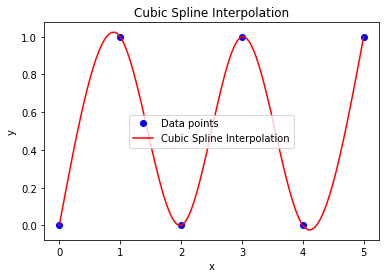

In [3]:
# Plot the original data and cubic spline interpolation
plt.plot(x, y, 'bo', label="Data points")
plt.plot(x_interp, y_interp, 'r-',
label="Cubic Spline Interpolation")
plt.title("Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

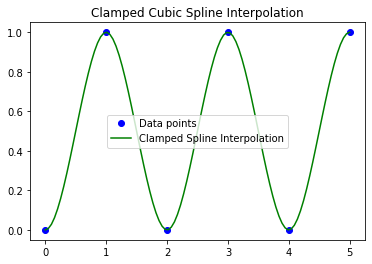

In [4]:
# Create a clamped cubic spline interpolation
cs_clamped = CubicSpline(x, y, bc_type=((1, 0), (1, 0)))
# Interpolated points
y_clamped_interp = cs_clamped(x_interp)
# Plot the clamped cubic spline interpolation
plt.plot(x, y, 'bo', label="Data points")
plt.plot(x_interp, y_clamped_interp, 'g-', label="Clamped Spline Interpolation")
plt.title("Clamped Cubic Spline Interpolation")
plt.legend()
plt.show()

Polynomial Coefficients:  [-5.85559710e-16  7.40740741e-02 -5.55555556e-01  1.10052910e+00
  6.34920635e-02]


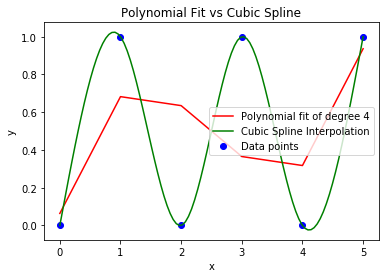

In [9]:
# Step 2: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data
degree = 4 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)
# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)
# Step 3: Use the coefficients to predict y-values (polynomial function)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(x)
# Step 4: Plotting the results
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.plot(x_interp, y_interp, 'g-',
label="Cubic Spline Interpolation")
plt.title('Polynomial Fit vs Cubic Spline')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [15]:
import numpy as np
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*(((y[i+1]-y[i])/h[i])-((y[i]-y[i-1])/h[i-1])) # Right-hand side vector
    return A, B, C, D

In [16]:
# Example data points
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

# Set up the tridiagonal matrix for the cubic spline
A, B, C, D = setup_tridiagonal_matrix(x, y)

print("Subdiagonal (A):", A)
print("Main diagonal (B):", B)
print("Superdiagonal (C):", C)
print("Right-hand side (D):", D)

Subdiagonal (A): [1. 1. 1. 1.]
Main diagonal (B): [4. 4. 4. 4.]
Superdiagonal (C): [1. 1. 1. 1.]
Right-hand side (D): [-12.  12. -12.  12.]


In [17]:
import numpy as np
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [18]:
# Example: solve a tridiagonal system
a = [1, 1, 1, 1] # Sub-diagonal (a_2, a_3, ..., a_n)
b = [4, 4, 4, 4, 4] # Main diagonal (b_1, b_2, ..., b_n)
c = [1, 1, 1, 1] # Super-diagonal (c_1, c_2, ..., c_{n-1})
d = [5, 6, 6, 6, 5] # Right-hand side (d_1, d_2, ..., d_n)
# Solve the system
x = thomas_algorithm(a, b, c, d)
print("Solution:", x)
# returns second derivatives!

Solution: [1. 1. 1. 1. 1.]
